# Load Required Libraries
### Notes on Important Packages
* **LabelEncoder**: converts categorical labels into integer codes like {0, 1, 2, ...}, primarily used for encoding **target variables (y)** under multi-class classifications
    * It is not appropriate for encoding categorical input features because it introduces artificial ordinal relationships; instead, one hot encoding (or multi-hot encoding) should be used
* **missingno**: visualizes missing data patterns; helps us understand whether missingness is structured, which variables have missing values, and the correlation between missingness
* **enable_iterative_imputer**: enables experimental feature to use IterativeImputer
* **IterativeImputer**: performs multivariate imputation using regression models; implements MICE (Multiple Imputation by Chained Equations), a strategy for imputing missing values by modeling each feature with missing values as a function of other features in a round-robin fashion (https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html)

In [51]:
import random
random.seed(17093890)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# imputation
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns

# dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# classifiers
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# metrics
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize #converts multiclass labels into multiple binary labels

# Data and Task

## Dataset

This project uses a Spotify music dataset containing 50,000 randomly sampled songs.  
The dataset includes a variety of audio features extracted via the Spotify API, such as Popularity, Tempo, Duration, etc. Each song is labeled with one of 10 music genres (e.g., Rock, Country, Pop, etc.).

The dataset contains both numerical and categorical features, and includes a small amount of missing data.

## Task

The objective of this project is to build a supervised multi-class classification model that predicts the genre of a song based on its audio features. Given a set of feature vectors X and corresponding genre labels y, the task is to learn a function: $f(X) \rightarrow y$ where y ∈ {10 possible genres}.

Model performance is evaluated using multi-class ROC-AUC on a strictly separated test set.

This project compares LDA + SVM with CatBoost.

# 1. Preperations and Cleaning
Basic cleaning procedures (procedures that do not reply on rest of the data) are done before train-test-split.

In [52]:
# import data
data = pd.read_csv("musicDataCopy.csv")

# drop columns that are not included for classification
data = data.drop(columns=['instance_id','artist_name','track_name','obtained_date'])

# display basic information
print("\nDataset Overview")
print(f"Total number of songs: {data.shape[0]}")
print(f"Total number of genres: {data['music_genre'].nunique()}")
data.head(5)


Dataset Overview
Total number of songs: 50005
Total number of genres: 10


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,0.759,Electronic
1,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,0.531,Electronic
2,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
3,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
4,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic


In [53]:
# Null value cleaning

# drop empty rows, reset index
data = data.dropna(how="all").reset_index(drop=True)
print("Check null values:")
print(data.isnull().sum(axis=0))

Check null values:
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
valence             0
music_genre         0
dtype: int64


## Sentinel Missing Values Cleaning
For some features, missing values are encoded as sentinel values (out-of-range value, -1, ?, etc) rather than NaN. This section aims to locate these sentinel values and convert them to NaN.

In [54]:
# Sentinel missing values cleaning

# columns with range [0, 1]
cols_01 = ["acousticness", "danceability", "energy",
           "instrumentalness", "liveness", "speechiness", "valence"]

# convert to NaN if not numeric
numeric = data[cols_01].apply(pd.to_numeric, errors="coerce")

# count invalid values (below 0, above 1, or NaN)
out_of_range_total = ((numeric < 0) | (numeric > 1) | (numeric.isna())).sum(axis=0)
print("Out of range values for 0~1 bounded features:")
print(out_of_range_total)

Out of range values for 0~1 bounded features:
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
speechiness         0
valence             0
dtype: int64


### 'duration_ms' and 'tempo' contain sentinel missing values in the forms of -1 and "?".

In [55]:
print(data[['duration_ms', 'tempo']].head(10))

   duration_ms               tempo
0         -1.0             100.889
1     218293.0  115.00200000000001
2     215613.0             127.994
3     166875.0             128.014
4     222369.0             145.036
5     519468.0                   ?
6     214408.0             149.995
7     416132.0             120.008
8     292800.0  149.94799999999998
9     204800.0             139.933


In [56]:
# check duration (-1), tempo (?)
invalid_counts = {}

duration = pd.to_numeric(data["duration_ms"], errors="coerce")
invalid_counts["duration_ms"] = ((duration == -1)).sum()

tempo = data["tempo"].astype(str).str.strip()
invalid_counts["tempo"] = (tempo == "?").sum()

invalid_counts = pd.Series(invalid_counts)
print("Duration, tempo missing values:")
print(invalid_counts)

# convert sentinel missing values to NaN
data.loc[data["duration_ms"] == -1, "duration_ms"] = np.nan
data.loc[data["tempo"] == "?", "tempo"] = np.nan

# convert duration and tempo to numeric columns
data["duration_ms"] = pd.to_numeric(data["duration_ms"], errors="coerce")
data["tempo"] = pd.to_numeric(data["tempo"], errors="coerce")

Duration, tempo missing values:
duration_ms    4939
tempo          4980
dtype: int64


### The only two columns with missing values are 'duration_ms' and 'tempo', each with roughly **10%** missing values. Since this level of missingness is non-negligible, appropriate **imputation method** is preferred rather than dropping incomplete rows or columns directly.

In [57]:
# check cleaning results (missing values should all be in NaN form)
data.head(10)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,27.0,0.00468,0.652,NaN,0.941,0.792000,A#,0.1150,-5.201,Minor,0.0748,100.889,0.759,Electronic
1,31.0,0.01270,0.622,218293.0,0.890,0.950000,D,0.1240,-7.043,Minor,0.0300,115.002,0.531,Electronic
2,28.0,0.00306,0.620,215613.0,0.755,0.011800,G#,0.5340,-4.617,Major,0.0345,127.994,0.333,Electronic
3,34.0,0.02540,0.774,166875.0,0.700,0.002530,C#,0.1570,-4.498,Major,0.2390,128.014,0.270,Electronic
4,32.0,0.00465,0.638,222369.0,0.587,0.909000,F#,0.1570,-6.266,Major,0.0413,145.036,0.323,Electronic
5,47.0,0.00523,0.755,519468.0,0.731,0.854000,D,0.2160,-10.517,Minor,0.0412,NaN,0.614,Electronic
6,46.0,0.02890,0.572,214408.0,0.803,0.000008,B,0.1060,-4.294,Major,0.3510,149.995,0.230,Electronic
7,43.0,0.02970,0.809,416132.0,0.706,0.903000,G,0.0635,-9.339,Minor,0.0484,120.008,0.761,Electronic
8,39.0,0.00299,0.509,292800.0,0.921,0.000276,F,0.1780,-3.175,Minor,0.2680,149.948,0.273,Electronic
9,22.0,0.00934,0.578,204800.0,0.731,0.011200,A,0.1110,-7.091,Minor,0.1730,139.933,0.203,Electronic


## Encode Non-numeric Features + Target
Although CatBoost **does not require encoding of categorical columns**, but raw categorical strings do not work for LDA or SVM. Therefore we will numerically encode categorical columns, and later specify categorical columns as 'cat_features' when implementing CatBoost.

In [58]:
# mode mapped to major = 1, minor = 0
mode_map = {'Major': 1, 'Minor': 0}
data['mode'] = data['mode'].map(mode_map)

# keys mapped to numeric values 0-11
keys = {'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5, 'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11}
data["key"] = data["key"].map(keys)

# target (y): music genres are encoded using LabelEncoder
le = LabelEncoder()
data["music_genre"] = le.fit_transform(data["music_genre"])

# see encoding results
data.head(5)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,27.0,0.00468,0.652,NaN,0.941,0.79200,10,0.115,-5.201,0,0.0748,100.889,0.759,5
1,31.0,0.01270,0.622,218293.0,0.890,0.95000,2,0.124,-7.043,0,0.0300,115.002,0.531,5
2,28.0,0.00306,0.620,215613.0,0.755,0.01180,8,0.534,-4.617,1,0.0345,127.994,0.333,5
3,34.0,0.02540,0.774,166875.0,0.700,0.00253,1,0.157,-4.498,1,0.2390,128.014,0.270,5
4,32.0,0.00465,0.638,222369.0,0.587,0.90900,6,0.157,-6.266,1,0.0413,145.036,0.323,5


# 2. Train/Test Split
Now the dataset is structurally cleaned, we can move on with train/test split and preprocessing pipelines. Because CatBoost handles missing data internally, a raw copy for train and test sets is created for comparisons (https://catboost.ai/docs/en/concepts/algorithm-missing-values-processing).

In [59]:
# Train/Test Split

# separate the feature and target
X = data.drop(columns=["music_genre"])
y = data["music_genre"]

# extract test set: 500 random rows per genre (which is 10% of original size)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.1, 
                                                    random_state=17093890, 
                                                    stratify=y) # takes class proportions into account

# keep raw copies for CatBoost, which will not be imputed
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

print("Counts per music genre in training set:")
print(y_train.value_counts().sort_index())

print("\nCounts per music genre in testing set:")
print(y_test.value_counts().sort_index())

Counts per music genre in training set:
music_genre
0    4500
1    4500
2    4500
3    4500
4    4500
5    4500
6    4500
7    4500
8    4500
9    4500
Name: count, dtype: int64

Counts per music genre in testing set:
music_genre
0    500
1    500
2    500
3    500
4    500
5    500
6    500
7    500
8    500
9    500
Name: count, dtype: int64


# 3. Preprocessing Pipelines
## Pipeline A: CatBoost
Minimal preprocessing, no feature scaling or missing value imputation needed.
## Pipeline B: LDA/SVM
Imputation + feature scaling.
To avoid leakage, the imputer is fitted exclusively on the training data, and then the learned parameters are applied to both the training and test sets.   

## To choose the most appropriate imputer, we begin by visualizing the missing value distribution.

<Axes: >

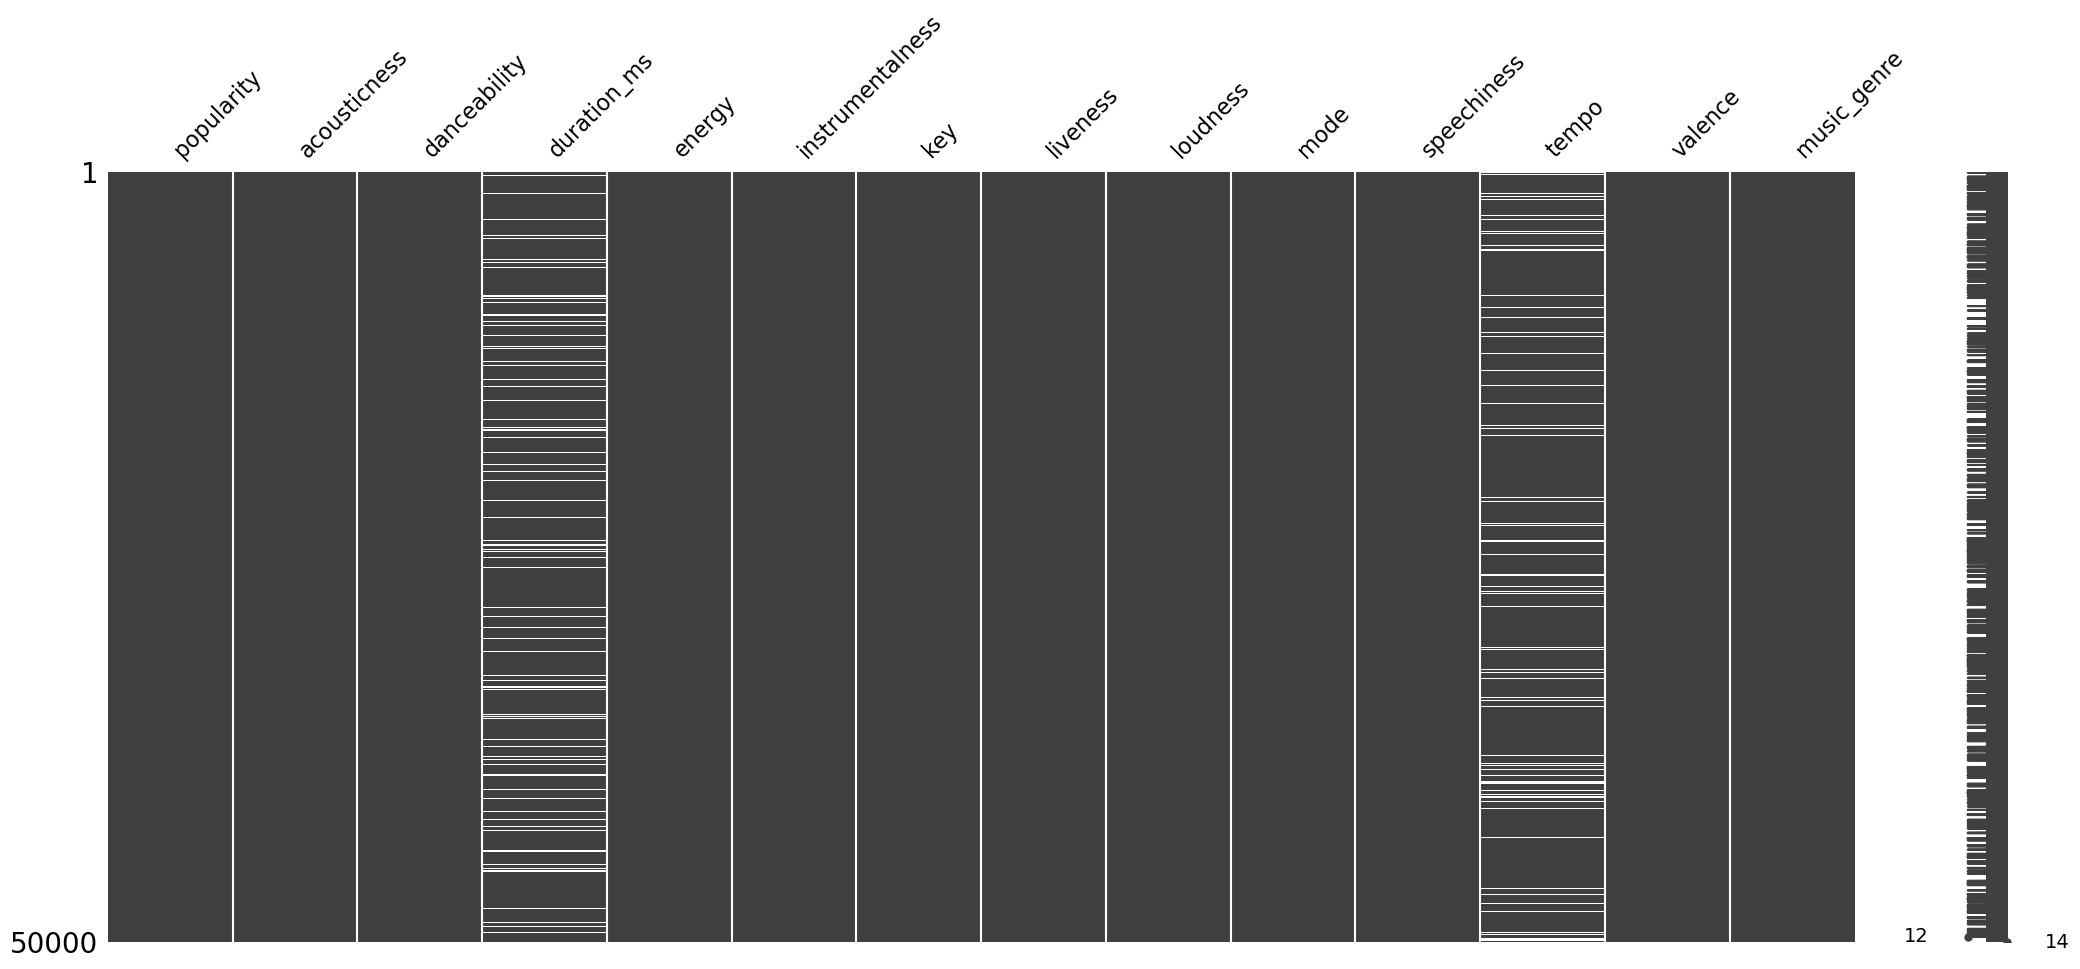

In [60]:
# visualize missing value distribution 
msno.matrix(data) 

# the missingness of tempo and duration seem unstructured across rows
# which implies a low possibility of MNAR

# MICE: Multivariate Imputation by Chained-Equations

* **Assumption**: Missing data are Missing At Random (MAR), which the current dataset fulfills
* Algorithm: MICE fills missing values by modeling each feature as a function of the others, iterativel

### To avoid leakage, the MICE imputer is fit only on training set data, then applied to test set data

### We compare the distribution and statistics of the dataset before and after imputation, as a way to evaluate the imputation validity

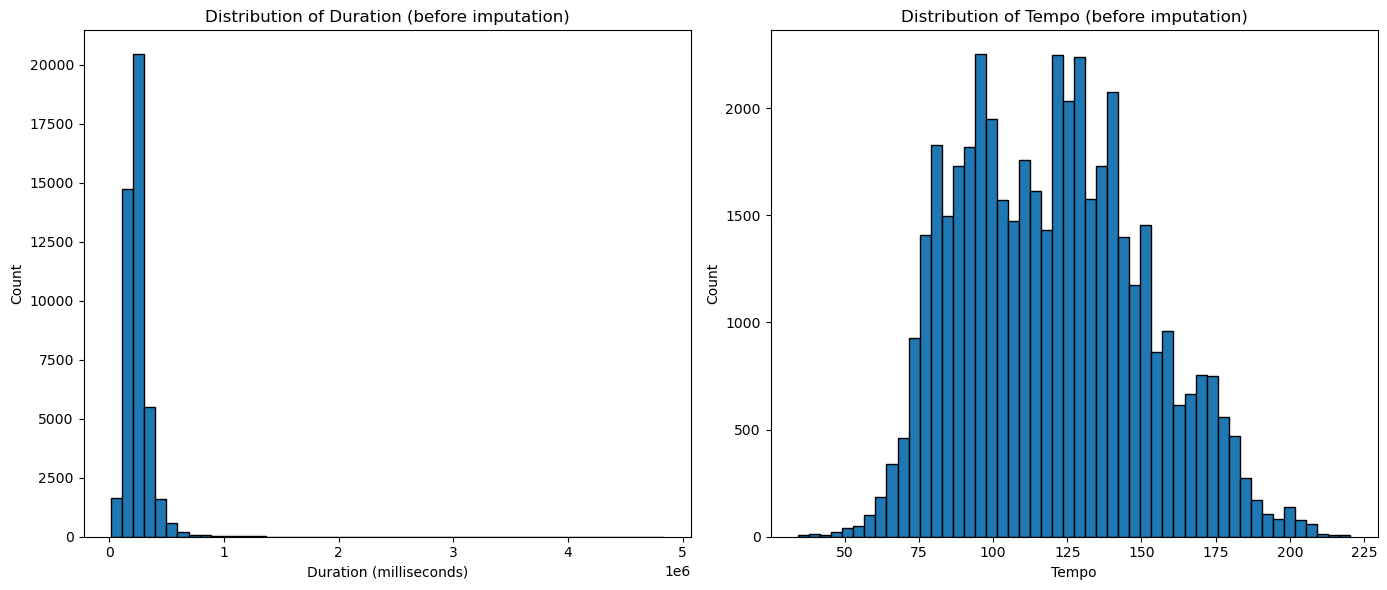

In [70]:
# visualize tempo and duration distributions before imputation
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(X_train["duration_ms"], bins=50, edgecolor='black')
plt.title("Distribution of Duration (before imputation)")
plt.xlabel("Duration (milliseconds)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(X_train["tempo"], bins=50, edgecolor='black')
plt.title("Distribution of Tempo (before imputation)")
plt.xlabel("Tempo")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [71]:
# Before imputation statistics

print("Before imputation statistics (duration and tempo, respectively): ")
print()
print(X_train["duration_ms"].describe())
print()
print(X_train["tempo"].describe())

Before imputation statistics (duration and tempo, respectively): 

count    4.500000e+04
mean     2.464245e+05
std      1.119938e+05
min      1.550900e+04
25%      1.896670e+05
50%      2.285880e+05
75%      2.802735e+05
max      4.830606e+06
Name: duration_ms, dtype: float64

count    45000.000000
mean       119.939974
std         30.595491
min         34.347000
25%         95.005750
50%        119.879000
75%        140.396016
max        220.276000
Name: tempo, dtype: float64


In [63]:
# Prepare for Imputation

# extract features used for imputation
impute_features = ['duration_ms', 'tempo','popularity', 'acousticness', 
                   'danceability', 'energy', 'instrumentalness', 'key', 
                   'liveness', 'loudness', 'mode', 'speechiness','valence']

# set up min and max bounds for duration and tempo; 
# the bounds used are the empirical min max of the training data 

dur_min, dur_max = X_train["duration_ms"].min(), X_train["duration_ms"].max()
tempo_min, tempo_max = X_train["tempo"].min(), X_train["tempo"].max()
print("Min and max value used to restrict imputation range:")
print("Duration:", dur_min, dur_max)
print("Tempo:", tempo_min, tempo_max)
print()

Min and max value used to restrict imputation range:
Duration: 15509.0 4830606.0
Tempo: 34.347 220.276



In [64]:
n_features = len(impute_features)

# construct bound arrays (only constrain duration + tempo, for others the bounds are negative/positive infinity)
min_bounds = np.array([dur_min, tempo_min] + [-np.inf] * (n_features - 2))
max_bounds = np.array([dur_max, tempo_max] + [np.inf] * (n_features - 2))

# extract train / test subsets for imputation
X_train_imp_df = X_train[impute_features].copy()
X_test_imp_df  = X_test[impute_features].copy()

## Imputation

* Imputer fit on training set only
* Imputer definition: median value is used for step 0 iteration to make imputation more robust to outliers

In [65]:
# define imputer: MICE with default regressor (default=BayesianRidge())
imputer = IterativeImputer(max_iter=20, random_state=17093890,
                           initial_strategy='median', imputation_order='random', 
                           min_value=min_bounds, max_value=max_bounds,
                           skip_complete=True, sample_posterior=True)

# fit on train
X_train_imputed = imputer.fit_transform(X_train_imp_df)

# transform test
X_test_imputed = imputer.transform(X_test_imp_df)

# convert back to DataFrame
X_train_imputed = pd.DataFrame(X_train_imputed, columns=impute_features, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=impute_features, index=X_test.index)

# replace inputed duration and tempo column
X_train["duration_ms"] = X_train_imputed["duration_ms"]
X_train["tempo"] = X_train_imputed["tempo"]

X_test["duration_ms"] = X_test_imputed["duration_ms"]
X_test["tempo"] = X_test_imputed["tempo"]

# double check if now missing values = 0
print("Train missing after MICE:")
print(X_train[["duration_ms", "tempo"]].isnull().sum())

print("Test missing after MICE:")
print(X_test[["duration_ms", "tempo"]].isnull().sum())
print()

# double check if many imputed data is out of range
print("Train bounds check:")
print("Any duration below dur_min?", (X_train["duration_ms"] < dur_min).any())
print("Any duration above dur_max?", (X_train["duration_ms"] > dur_max).any())
print("Any tempo below tempo_min?", (X_train["tempo"] < tempo_min).any())
print("Any tempo above tempo_max?", (X_train["tempo"] > tempo_max).any())

print()

print("Test bounds check:")
print("Any duration below dur_min?", (X_test["duration_ms"] < dur_min).any())
print("Any duration above dur_max?", (X_test["duration_ms"] > dur_max).any())
print("Any tempo below tempo_min?", (X_test["tempo"] < tempo_min).any())
print("Any tempo above tempo_max?", (X_test["tempo"] > tempo_max).any())

Train missing after MICE:
duration_ms    0
tempo          0
dtype: int64
Test missing after MICE:
duration_ms    0
tempo          0
dtype: int64
Train bounds check:
Any duration below dur_min? False
Any duration above dur_max? False
Any tempo below tempo_min? False
Any tempo above tempo_max? False

Test bounds check:
Any duration below dur_min? False
Any duration above dur_max? False
Any tempo below tempo_min? False
Any tempo above tempo_max? False


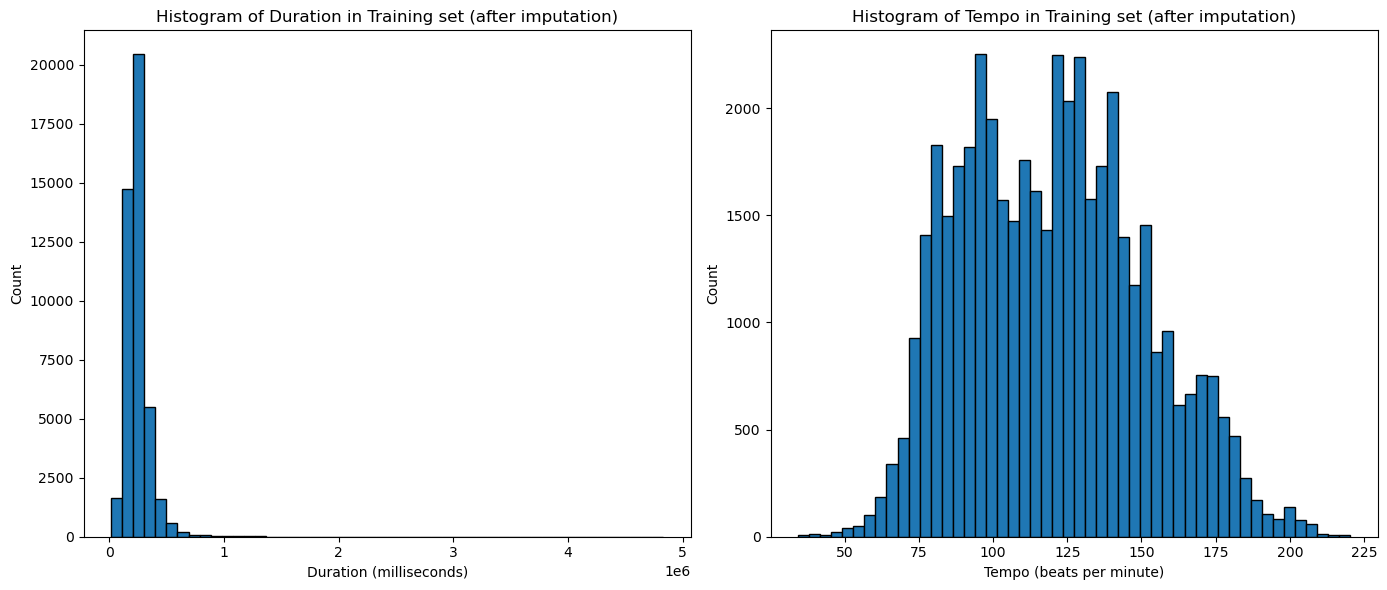

After imputation statistics (duration and tempo): 

count    4.500000e+04
mean     2.464245e+05
std      1.119938e+05
min      1.550900e+04
25%      1.896670e+05
50%      2.285880e+05
75%      2.802735e+05
max      4.830606e+06
Name: duration_ms, dtype: float64

count    45000.000000
mean       119.939974
std         30.595491
min         34.347000
25%         95.005750
50%        119.879000
75%        140.396016
max        220.276000
Name: tempo, dtype: float64


In [69]:
# visualize tempo and duration distribution after imputation
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(X_train["duration_ms"], bins=50, edgecolor='black')
plt.title("Histogram of Duration (after imputation)")
plt.xlabel("Duration (milliseconds)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(X_train["tempo"], bins=50, edgecolor='black')
plt.title("Histogram of Tempo (after imputation)")
plt.xlabel("Tempo (beats per minute)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [72]:
# statistics after imputation
print("After imputation statistics (duration and tempo): ")
print()
print(X_train["duration_ms"].describe())
print()
print(X_train["tempo"].describe())

After imputation statistics (duration and tempo): 

count    4.500000e+04
mean     2.464245e+05
std      1.119938e+05
min      1.550900e+04
25%      1.896670e+05
50%      2.285880e+05
75%      2.802735e+05
max      4.830606e+06
Name: duration_ms, dtype: float64

count    45000.000000
mean       119.939974
std         30.595491
min         34.347000
25%         95.005750
50%        119.879000
75%        140.396016
max        220.276000
Name: tempo, dtype: float64


# 4. Feature Scaling (Standardization)

### For models like SVM, PCA, and LDA, feature standardization is essential as these methods are sensitive to feature scales and can become biased when variables with larger magnitudes dominate.
### However, tree-based algorithms like CatBoost work naturally with unscaled data.

In [75]:
# only continuous numeric columns need to be scaled
scale_cols = ['popularity','acousticness','danceability','duration_ms', 
              'energy','instrumentalness','liveness','loudness','speechiness', 
              'tempo','valence']

# set up scaler and fit using training set
scaler = StandardScaler()
scaler.fit(X_train[scale_cols])

# transform and assign back
X_train.loc[:, scale_cols] = scaler.transform(X_train[scale_cols])
X_test.loc[:, scale_cols] = scaler.transform(X_test[scale_cols])

# check scaling effect
print("X_train means:")
print(X_train[scale_cols].mean())

print("\nX_train std:")
print(X_train[scale_cols].std())

X_train_scaled means:
popularity          1.326346e-17
acousticness        5.210647e-18
danceability        1.705303e-17
duration_ms        -5.052748e-18
energy             -7.105427e-18
instrumentalness    2.526374e-17
liveness           -1.421085e-17
loudness            4.736952e-18
speechiness        -5.368545e-18
tempo              -2.368476e-17
valence            -6.315935e-18
dtype: float64

X_train_scaled std:
popularity          1.000011
acousticness        1.000011
danceability        1.000011
duration_ms         1.000011
energy              1.000011
instrumentalness    1.000011
liveness            1.000011
loudness            1.000011
speechiness         1.000011
tempo               1.000011
valence             1.000011
dtype: float64


# 5. Dimensionality Reduction and Clustering

* Dimensionality reduction is crutial for this dataset, in that:
    * (1) It helps to reduce the dimension of the dataset, avoid (but not fully) curse of dimensionality
    * (2) Removes collinearity in features
    * (3) Removes noise

## EDA: before dimensioanlity reduction, we did exploratory data analysis to learn more about the relationships between features, and across genres

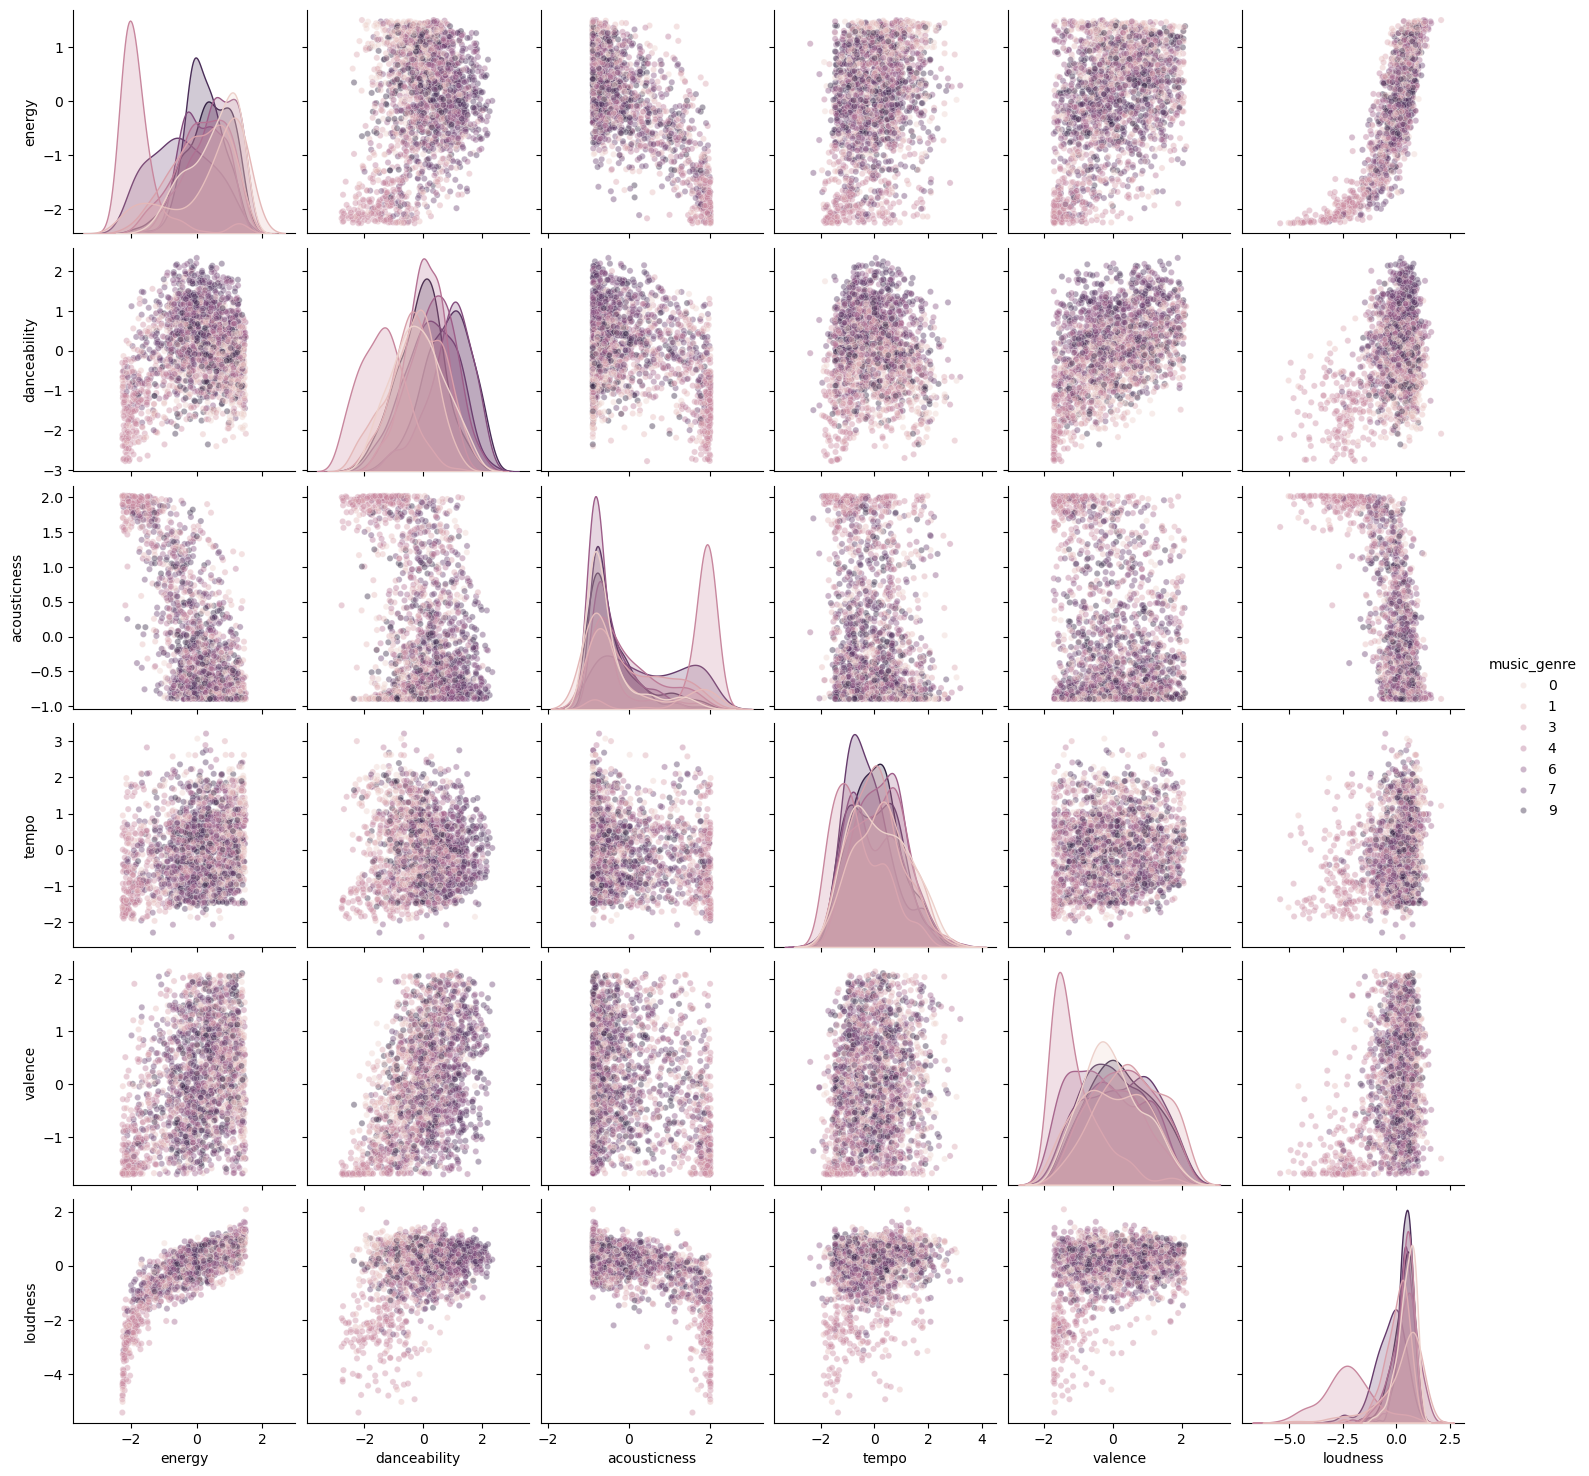

In [76]:
# simple EDA first: pair plot on selected features (not all features are included)
subset = ['energy', 'danceability', 'acousticness', 'tempo', 'valence', 
          'loudness']

# randomly sample 2000 instances from the training set to do pair plot
sample_df = pd.concat([X_train[subset], y_train], axis=1).sample(
            n=2000, random_state=17093890)

sns.pairplot(sample_df, hue='music_genre', plot_kws={'alpha': 0.4, 's': 20})

# Principle Component Analysis (PCA)
## PCA is a linear dimensionality reduction algorithm that aims to find a new coordinate system (with orthogonal basis) that explains the variance in the data as efficiently as possible; it removes redundant information and reduces the dimension of the data for downstream analysis or visualization purposes

In [77]:
# fit PCA on continuous features only, on training set only
pca_cols = scale_cols 

# make a copy of the continuous training set
pca_input = X_train.loc[:, pca_cols].copy()

# fit pca on the copy
pca_full = PCA()
pca_full.fit(pca_input)

eigenvalues = pca_full.explained_variance_
print("Eigenvalue per component:", eigenvalues)
print()

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("PCA: Explained variance per component:")
for i, var in enumerate(explained_variance[:]): 
    print(f"PC{i+1}: {var:.4f}")
    
print("\nPCA: Cumulative explained variance:")
for i, cv in enumerate(cumulative_variance[:]):
    print(f"PC1 to PC{i+1}: {cv:.4f}")

Eigenvalue per component: [3.71867302 1.35222959 1.05533059 0.97272031 0.94474326 0.81168122
 0.72533864 0.59379375 0.45936101 0.25609538 0.11027768]

PCA: Explained variance per component:
PC1: 0.3381
PC2: 0.1229
PC3: 0.0959
PC4: 0.0884
PC5: 0.0859
PC6: 0.0738
PC7: 0.0659
PC8: 0.0540
PC9: 0.0418
PC10: 0.0233
PC11: 0.0100

PCA: Cumulative explained variance:
PC1 to PC1: 0.3381
PC1 to PC2: 0.4610
PC1 to PC3: 0.5569
PC1 to PC4: 0.6453
PC1 to PC5: 0.7312
PC1 to PC6: 0.8050
PC1 to PC7: 0.8710
PC1 to PC8: 0.9249
PC1 to PC9: 0.9667
PC1 to PC10: 0.9900
PC1 to PC11: 1.0000


### PCA Result Plotting

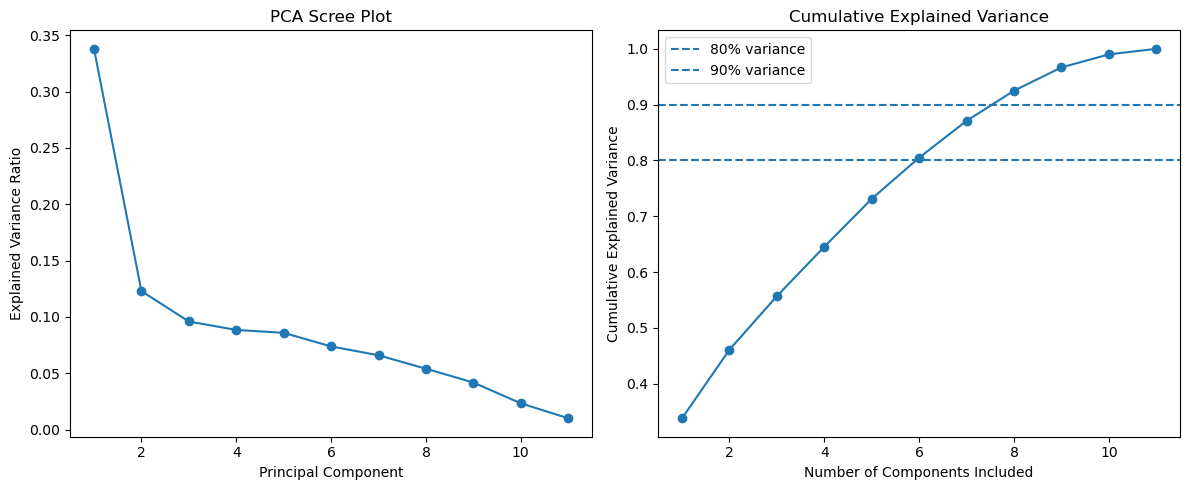

In [78]:
# scree plot and cumulative explained variance plot
n_components = len(explained_variance)

plt.figure(figsize=(12, 5))

# scree plot
plt.subplot(1, 2, 1)
plt.plot(range(1, n_components + 1),
         explained_variance,
         marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")

# explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, n_components + 1),
         cumulative_variance,
         marker='o')
plt.axhline(y=0.80, linestyle='--', label='80% variance')
plt.axhline(y=0.90, linestyle='--', label='90% variance')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components Included")
plt.ylabel("Cumulative Explained Variance")
plt.legend()

plt.tight_layout()
plt.show()

### Looking at the (cumulative) explained variances from PCA helps us decide how much principle components to retain. The first eight principle components collectively account for 92% of the variance in the data, which could be a good cut-off point

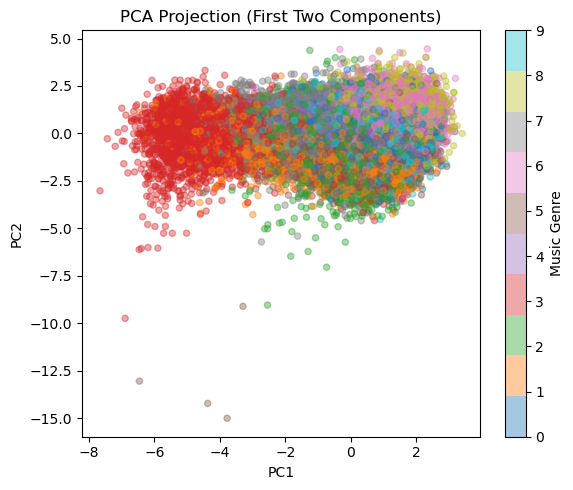

In [79]:
# visualize PCA result in 2D
pca_2 = PCA(n_components=2)
X_train_pca2 = pca_2.fit_transform(pca_input) 

plt.figure(figsize=(6, 5))

scatter = plt.scatter(X_train_pca2[:, 0], X_train_pca2[:, 1],
                      c=y_train, # color the points based on labels
                      cmap='tab10', alpha=0.4, s=20)
plt.title("PCA Projection (First Two Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Music Genre")
plt.tight_layout()
plt.show()

# PCA preserves variance but fails to clearly separate genres
# this motivates the use of supervised dimensionality reduction via LDA

# for PCA I use upto PC8 and + remaining 2 categorical columns
# this gives a dimension reduced model with 10 features (vs. 13)
# even though the dimension was not greatly reduced, but this is due to
# PCA Is linear, the data contain non linear relationship, and also PCA
# help reduce noise and redundancy, so does make sense and is useful

# t-SNE should not be used since it is non-parametric, so it won't realy work
# t-SNE learns a mapping for the training data only; 
# it doesn't learn a generalizable function to transform new, 
# unseen data into the low-dimensional space, which is essential for a classifier

### PCA preserves variance but fails to clearly separate genres. There are still substantial overlap under 2D PCA projection. This is because while choosing principle components, PCA does not take class labels into account, and the directions that maximizes variance might not maximize class separability. This motivates the use of supervised dimensionality reduction method like LDA.

# Linear Discriminant Analysis (LDA)
### LDA aims to preserve class separability while reducing the dimension of the dataset. It maximizes the distances between the projected class' means, and minimizes the variance within the projected class

In [81]:
# LDA should only be applied to scaled continuous features
lda_cols = scale_cols

# make a copy for lda
lda_input = X_train.loc[:, lda_cols].copy()

# fit using copied training data, including the labels
lda_full = LinearDiscriminantAnalysis(solver='svd', n_components=9) # full = fit on the entire data set
lda_full.fit(lda_input, y_train) 

LinearDiscriminantAnalysis(n_components=9)

### Explained variance ratios in LDA refers to the proportion of between-class variability (discriminability) captured by each linear discriminant, showing how much of the class separation each component accounts for

In [83]:
# LDA evaluation
explained = lda_full.explained_variance_ratio_
cumulative = np.cumsum(explained) 

print("\nLDA: Explained Variance Ratios (discriminability)")
for i, (v, c) in enumerate(zip(explained, cumulative)):
    print(f"LD{i+1}: {v:.4f}, cumulative: {c:.4f}")

# transform x_train using the fitted LDA (full component)
X_train_lda_all = lda_full.transform(X_train[scale_cols]) 


LDA: Explained Variance Ratios (discriminability)
LD1: 0.6504, cumulative: 0.6504
LD2: 0.1717, cumulative: 0.8221
LD3: 0.1066, cumulative: 0.9287
LD4: 0.0377, cumulative: 0.9664
LD5: 0.0229, cumulative: 0.9893
LD6: 0.0066, cumulative: 0.9959
LD7: 0.0037, cumulative: 0.9996
LD8: 0.0004, cumulative: 1.0000
LD9: 0.0000, cumulative: 1.0000


### LDA Projection Plotting
As we can see, LDA projection greatly reduces the overlap between genre clusters.

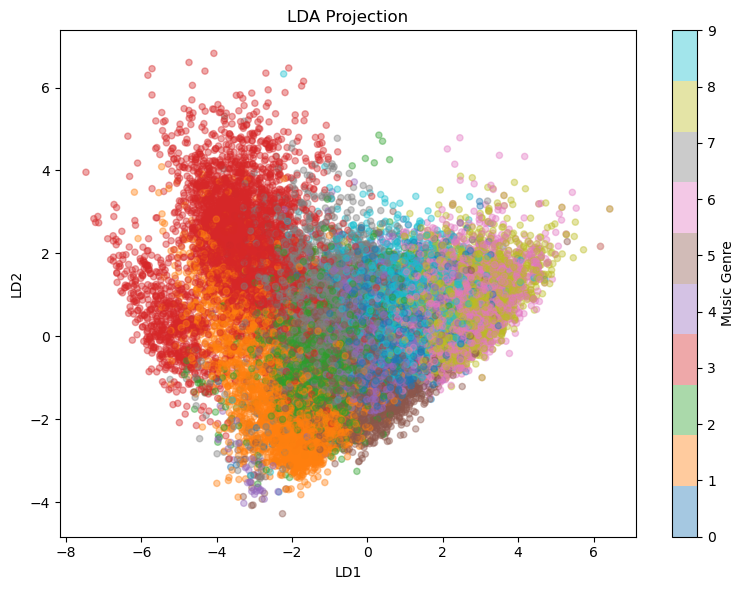

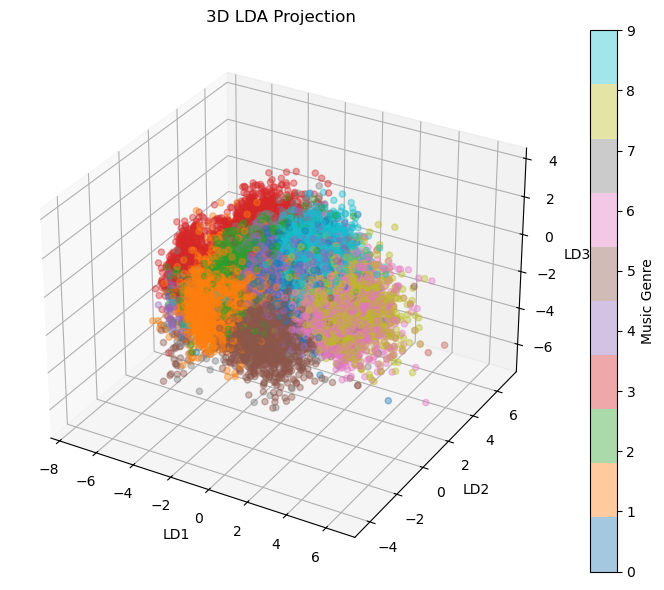

In [85]:
# visualize LDA result (2D)
X_train_lda2 = X_train_lda_all[:, :2]

plt.figure(figsize=(8, 6))

scatter = plt.scatter(X_train_lda2[:, 0], X_train_lda2[:, 1], c=y_train,
                      cmap='tab10', alpha=0.4, s=20)
plt.title("LDA Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.colorbar(scatter, label="Music Genre")
plt.tight_layout()
plt.show()

# visualize LDA result (3D)
X = X_train_lda_all[:, :3] 
y = y_train

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='tab10', alpha=0.4, s=20)

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_zlabel("LD3")
ax.set_title("3D LDA Projection")

fig.colorbar(scatter, ax=ax, label="Music Genre")
plt.tight_layout()
plt.show()

### From the projection results, it is clear that LDA is a better dimensionality reduction method to apply. So next we apply LDA transformation to the training and testing set (so that they live in the same dimension space).

Since the cumulative explained ratio reaches 96% around LD4, we will keep up to LD4 when transforming the data.


In [91]:
# transform testing set
X_test_lda_all  = lda_full.transform(X_test[scale_cols])

# retain 4 directions
X_train_lda4 = X_train_lda_all[:, :4]
X_test_lda4  = X_test_lda_all[:, :4]

# 6. Classification
## After dimensionality reduction, we apply two groups of classifier: (1) Linear SVM (with LDA projection), and (2) CatBoost (with raw data)

# Linear Support Vector Machine (SVM)

To take advantage of the linear boundaries learned by LDA, we first trained a linear Support Vector Machine on the LDA transformed feature space. Note the categorical features ‘mode’ and ‘key’ were not included for classification.  
A standard LinearSVC does not produce probability outputs, however without it we cannot plot AUC curves. Therefore the model was wrapped with a **calibration step** using Platt scaling (sigmoid calibration), which allows decision scores to be converted into class probabilities (https://scikit-learn.org/stable/modules/calibration.html)

In [92]:
# base linear SVM
svm_base = LinearSVC(C=1.0, class_weight="balanced", random_state=17093890)

# calibrate to output predicted probabilities
svm_cal = CalibratedClassifierCV(estimator=svm_base, method="sigmoid", cv=5)

# fit on LDA transformed lower dimensional data
svm_cal.fit(X_train_lda4, y_train)

# make predictions
y_pred4 = svm_cal.predict(X_test_lda4)
y_proba4 = svm_cal.predict_proba(X_test_lda4)

# evaluate performance
acc_svm = accuracy_score(y_test, y_pred4)
auc_svm = roc_auc_score(y_test, y_proba4, multi_class="ovr", average="macro")

print(f"Linear SVM (LD1–LD4) Accuracy: {acc_svm:.4f}")
print(f"Linear SVM (LD1–LD4) AUC (OvR, macro): {auc_svm:.4f}")

Linear SVM (LD1–LD4) Accuracy: 0.4808
Linear SVM (LD1–LD4) AUC (OvR, macro): 0.8776


## Plotting SVM AUC Performances

* **OvR One vs Rest**: a problem decomposition strategy for multi-class classification; converts a multi class problem into multiple binary class problems, where in each binary group, the target class = 1, and all other classes = 0;
* **Per-class ROC**: shows how well the model distinguishes one class vs. all other classes
* **Macro-averaged ROC**: average the ROC curves across all classes, tells us “How good is the model overall across all classes?”, assiging each class with equal weight

In [94]:
# define a function for plotting multiclass roc curve
# 2 plots: one including per class roc, the other one showing only macro roc

def plot_multiclass_roc(y_true, y_score, title_prefix, class_names=None):
  
    y_true = y_true.to_numpy() if hasattr(y_true, "to_numpy") else np.asarray(y_true)
    y_score = np.asarray(y_score)
    K = y_score.shape[1]

    if class_names is None:
        class_names = [f"class {k}" for k in range(K)]
    else:
        class_names = list(class_names)

    # binarize labels for OvR
    Y = label_binarize(y_true, classes=np.arange(K))

    # per-class ROC + AUC
    fpr, tpr, roc_auc = {}, {}, {}
    for k in range(K):
        fpr[k], tpr[k], _ = roc_curve(Y[:, k], y_score[:, k])
        roc_auc[k] = auc(fpr[k], tpr[k])

    # macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[k] for k in range(K)]))
    mean_tpr = np.zeros_like(all_fpr, dtype=float)
    for k in range(K):
        mean_tpr += np.interp(all_fpr, fpr[k], tpr[k])
    mean_tpr /= K
    macro_auc_curve = auc(all_fpr, mean_tpr)
    
    # plot 1: macro-average ROC
    plt.figure(figsize=(6, 5))
    plt.plot(all_fpr, mean_tpr, linewidth=2,
             label=f"Macro-average ROC (AUC = {macro_auc_curve:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Macro-average ROC Curve ({title_prefix})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # plot 2: per-class ROC curves + macro
    plt.figure(figsize=(8, 6))
    for k in range(K):
        plt.plot(fpr[k], tpr[k], linewidth=1.2, alpha=0.8,
                 label=f"{class_names[k]} (AUC = {roc_auc[k]:.2f})")

    plt.plot(all_fpr, mean_tpr, linestyle=":", linewidth=3,
             label=f"Macro-average ROC (AUC = {macro_auc_curve:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Per-class ROC Curves ({title_prefix})")
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.show()

    return macro_auc_curve, roc_auc

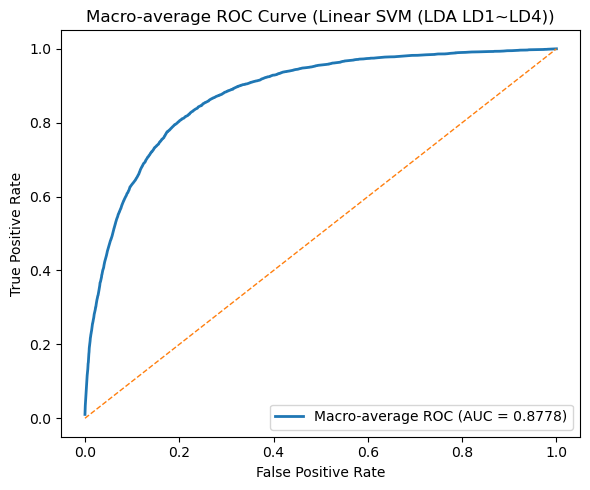

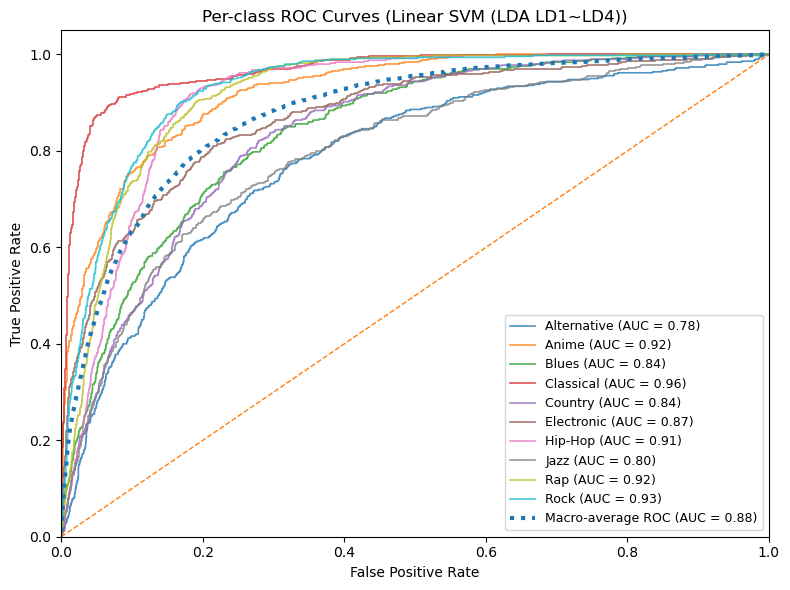

(np.float64(0.8777740666666666),
 {0: np.float64(0.7840593333333333),
  1: np.float64(0.9228257777777777),
  2: np.float64(0.840821111111111),
  3: np.float64(0.9649822222222222),
  4: np.float64(0.8355139999999999),
  5: np.float64(0.871736888888889),
  6: np.float64(0.9103155555555557),
  7: np.float64(0.7970182222222222),
  8: np.float64(0.9190271111111111),
  9: np.float64(0.9297326666666667)})

In [96]:
class_names = le.classes_

plot_multiclass_roc(y_true=y_test, y_score=y_proba4, 
                    title_prefix="Linear SVM (LDA LD1~LD4)",
                    class_names=class_names)

# CatBoost: Categorical Boosting

* Categorical Boosting = Gradient Boosting for Categorical Data, and it handles categorical data naturally
* It uses **Ordered Target Encoding** to encode categories without introducing data leakage, eliminating the need for extensive preprocessing like one-hot encoding
* As a tree-based algorithm, CatBoost requires no feature scaling
* CatBoost also handles missing values natively by learning optimal default directions in tree splits, avoiding the need for explicit imputation in many cases

In [97]:
# categorical boosting can be used since the dataset contains a mix of
# continuous and categorical data, it also works without dimensionalilty reduction

cat_cols = ['mode', 'key']
# extract categorical column indicies 
cat_index = [X_train_raw.columns.get_loc(c) for c in cat_cols]

# fit catboost
catboost = CatBoostClassifier(loss_function='MultiClass', # for multi class classification
                              eval_metric='MultiClass',iterations=500,
                              learning_rate=0.05, depth=6, random_seed=17093890,
                              verbose=200)

catboost.fit(X_train_raw, y_train, cat_features=cat_index, 
             eval_set=(X_test_raw, y_test), use_best_model=True)

0:	learn: 2.2053812	test: 2.2032951	best: 2.2032951 (0)	total: 144ms	remaining: 1m 11s
200:	learn: 1.0337808	test: 1.0426281	best: 1.0426281 (200)	total: 31.4s	remaining: 46.7s
400:	learn: 0.9598844	test: 0.9983929	best: 0.9983929 (400)	total: 1m 1s	remaining: 15.1s
499:	learn: 0.9377669	test: 0.9894344	best: 0.9894344 (499)	total: 1m 14s	remaining: 0us

bestTest = 0.9894343753
bestIteration = 499



In [98]:
# prediction and evalutation
y_pred_catboost = catboost.predict(X_test_raw).ravel()
y_proba_catboost = catboost.predict_proba(X_test_raw) 

acc_catboost = accuracy_score(y_test, y_pred_catboost)
auc_catboost = roc_auc_score(y_test, y_proba_catboost, multi_class='ovr', 
                             average='macro')

print(f"Test Accuracy: {acc_catboost:.4f}")
print(f"Test AUC (OvR, macro): {auc_catboost:.4f}")

Test Accuracy: 0.6164
Test AUC (OvR, macro): 0.9395


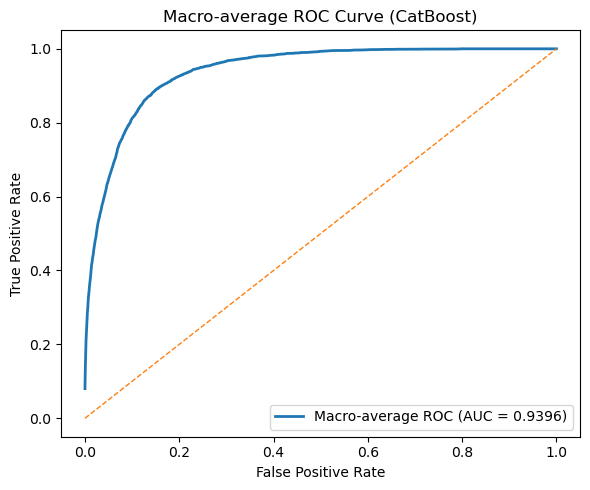

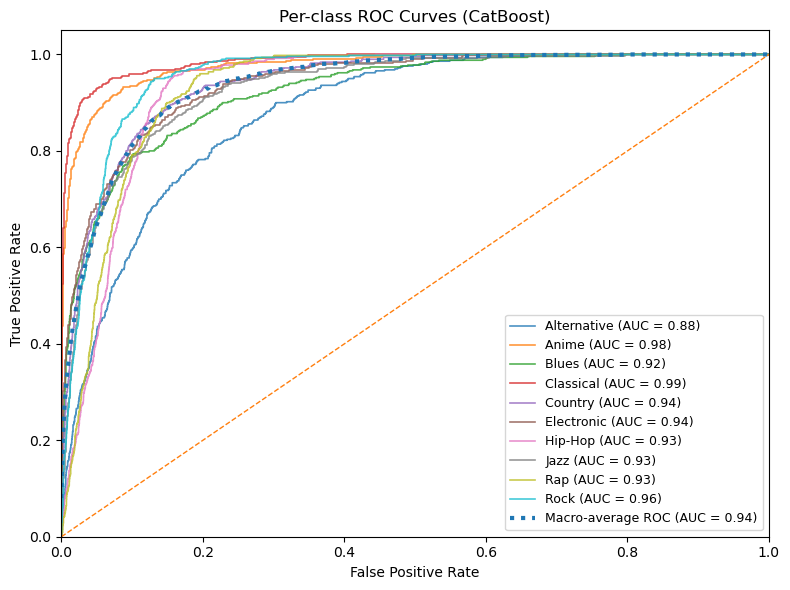

(np.float64(0.9396262666666668),
 {0: np.float64(0.8805282222222223),
  1: np.float64(0.9761288888888888),
  2: np.float64(0.924418888888889),
  3: np.float64(0.9851204444444445),
  4: np.float64(0.9411962222222223),
  5: np.float64(0.9400977777777778),
  6: np.float64(0.9306173333333334),
  7: np.float64(0.9303177777777778),
  8: np.float64(0.9312613333333334),
  9: np.float64(0.9551704444444443)})

In [99]:
# plot ROC
plot_multiclass_roc(y_true=y_test, y_score=y_proba_catboost, 
                    title_prefix="CatBoost", class_names=class_names)

# Dataset Summary Analysis and Summary

* The primary driver of our classification performance was the ability to capture nonlinear relationships and feature interactions among acoustic features.
* Exploratory data analysis (EDA), including feature visualizations and dimensionality reduction plots, provided important insights into the dataset structure prior to modeling.
* The 3D LDA projection revealed substantial overlap between certain genres, particularly rap and hip-hop, indicating that these classes are not linearly separable in the feature space.
* Preprocessing steps such as MICE imputation, feature scaling, and dimensionality reduction improved data quality and interpretability, but did not fully resolve class overlap.
* As a result, linear models (e.g., SVM) were inherently limited in their ability to distinguish between overlapping genres.
* In contrast, CatBoost, which does not rely on linearity or strict distributional assumptions, was able to capture complex nonlinear patterns and feature interactions, leading to superior classification performance.
* Additionally, the minimal performance change after correcting for imputation leakage suggests that the dataset contains strong underlying signal, and that model performance is driven more by feature relationships than preprocessing artifacts.

The end. Last Updated: 03/22/26